## Ejercicio 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def euler(f, t0, y0, h, n):
    t = np.zeros(n)
    y = np.zeros((n, len(y0)))

    t[0] = t0
    y[0] = y0

    for i in range(n-1):
        y[i+1] = y[i] + h * f(t[i], y[i])
        t[i+1] = t[i] + h

    return t, y

In [3]:
def rk2(f, t0, y0, h, n):
    t = np.zeros(n)
    y = np.zeros((n, len(y0)))

    t[0] = t0
    y[0] = y0

    for i in range(n-1):
        k1 = f(t[i], y[i])
        k2 = f(t[i] + h, y[i] + h*k1)

        y[i+1] = y[i] + (h/2)*(k1 + k2)
        t[i+1] = t[i] + h

    return t, y

In [4]:
def rk4(f, t0, y0, h, n):
    t = np.zeros(n)
    y = np.zeros((n, len(y0)))

    t[0] = t0
    y[0] = y0

    for i in range(n-1):
        k1 = f(t[i], y[i])
        k2 = f(t[i] + h/2, y[i] + h*k1/2)
        k3 = f(t[i] + h/2, y[i] + h*k2/2)
        k4 = f(t[i] + h, y[i] + h*k3)

        y[i+1] = y[i] + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
        t[i+1] = t[i] + h

    return t, y

In [5]:
def sistema1(t, y):
    x, v = y
    dxdt = v
    dvdt = -0.5*v - np.sin(x) + np.exp(-t)*(np.sin(3*t)+np.cos(2*t))
    return np.array([dxdt, dvdt])

In [6]:
y0 = np.array([0, 1])
t0 = 0
h = 0.05
n = 1000

t_e, y_e = euler(sistema1, t0, y0, h, n)
t_rk2, y_rk2 = rk2(sistema1, t0, y0, h, n)
t_rk4, y_rk4 = rk4(sistema1, t0, y0, h, n)

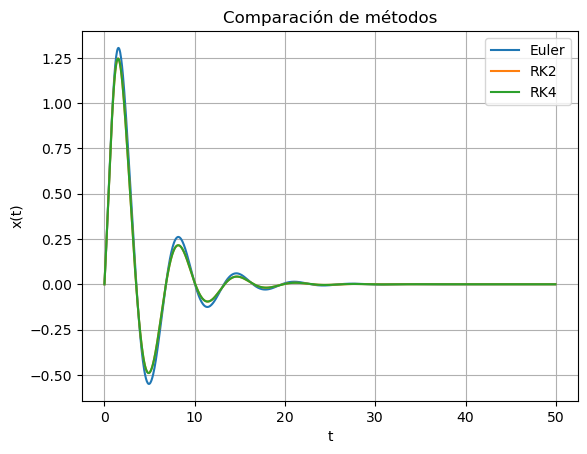

In [7]:
plt.figure()
plt.plot(t_e, y_e[:,0], label="Euler")
plt.plot(t_rk2, y_rk2[:,0], label="RK2")
plt.plot(t_rk4, y_rk4[:,0], label="RK4")
plt.legend()
plt.title("Comparación de métodos")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid()
plt.show()

In [8]:
## Ejercicio 2

In [9]:
def error_relativo(y1, y2):
    return np.abs((y1 - y2)/y2)

In [10]:
h1 = 0.05
h2 = 0.025

t1, y1 = rk4(sistema1, 0, y0, h1, int(5/h1))
t2, y2 = rk4(sistema1, 0, y0, h2, int(5/h2))

# Igualar tamaños
y2_interp = y2[::2]

error = error_relativo(y1[:,0], y2_interp[:,0])

print("Error máximo:", np.max(error))

Error máximo: nan


C:\Users\karin\AppData\Local\Temp\ipykernel_708\3336668720.py:2: RuntimeWarning: invalid value encountered in divide
  return np.abs((y1 - y2)/y2)
